In [2]:
import os
os.chdir(os.path.expanduser("~/ransomware_xai_project"))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data (same as notebook 1)
df = pd.read_csv("data/MalMem2022.csv")
drop_cols = ['Class', 'Category', 'Filename']
feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].copy()
y = (df['Class'] == 'Malware').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Data ready: Train {X_train_scaled.shape}, Test {X_test_scaled.shape}")

Data ready: Train (46876, 55), Test (11720, 55)


In [3]:
# Remove highly correlated features (|r| > 0.95)
corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [c for c in upper.columns if any(upper[c] > 0.95)]

print(f"Features BEFORE correlation filter: {X_train_scaled.shape[1]}")
print(f"Highly correlated features removed ({len(high_corr)}):")
for f in high_corr:
    print(f"  - {f}")

X_train_filtered = X_train_scaled.drop(columns=high_corr)
X_test_filtered = X_test_scaled.drop(columns=high_corr)
print(f"\nFeatures AFTER correlation filter: {X_train_filtered.shape[1]}")

Features BEFORE correlation filter: 55
Highly correlated features removed (22):
  - handles.nhandles
  - handles.avg_handles_per_proc
  - handles.nfile
  - handles.nevent
  - handles.nthread
  - handles.ndirectory
  - handles.ntimer
  - handles.nsection
  - ldrmodules.not_in_init
  - ldrmodules.not_in_mem
  - ldrmodules.not_in_mem_avg
  - malfind.protection
  - psxview.not_in_pspcid_list
  - psxview.not_in_csrss_handles
  - psxview.not_in_session
  - psxview.not_in_deskthrd
  - psxview.not_in_pslist_false_avg
  - psxview.not_in_pspcid_list_false_avg
  - psxview.not_in_csrss_handles_false_avg
  - psxview.not_in_session_false_avg
  - psxview.not_in_deskthrd_false_avg
  - svcscan.shared_process_services

Features AFTER correlation filter: 33


Top 20 features by Mutual Information:
                              feature  MI_score
                    svcscan.nservices  0.684398
            dlllist.avg_dlls_per_proc  0.671515
               svcscan.kernel_drivers  0.671462
                  pslist.avg_handlers  0.652568
                      handles.nmutant  0.650443
                         handles.nkey  0.629680
                        dlllist.ndlls  0.627260
                   handles.nsemaphore  0.618953
                   pslist.avg_threads  0.600613
               ldrmodules.not_in_load  0.582768
           ldrmodules.not_in_load_avg  0.554588
             malfind.uniqueInjections  0.554535
                      svcscan.nactive  0.476808
           ldrmodules.not_in_init_avg  0.475498
                 malfind.commitCharge  0.468252
             svcscan.process_services  0.393512
                         pslist.nppid  0.363741
                 callbacks.ncallbacks  0.303624
psxview.not_in_ethread_pool_false_avg  0.249598
 

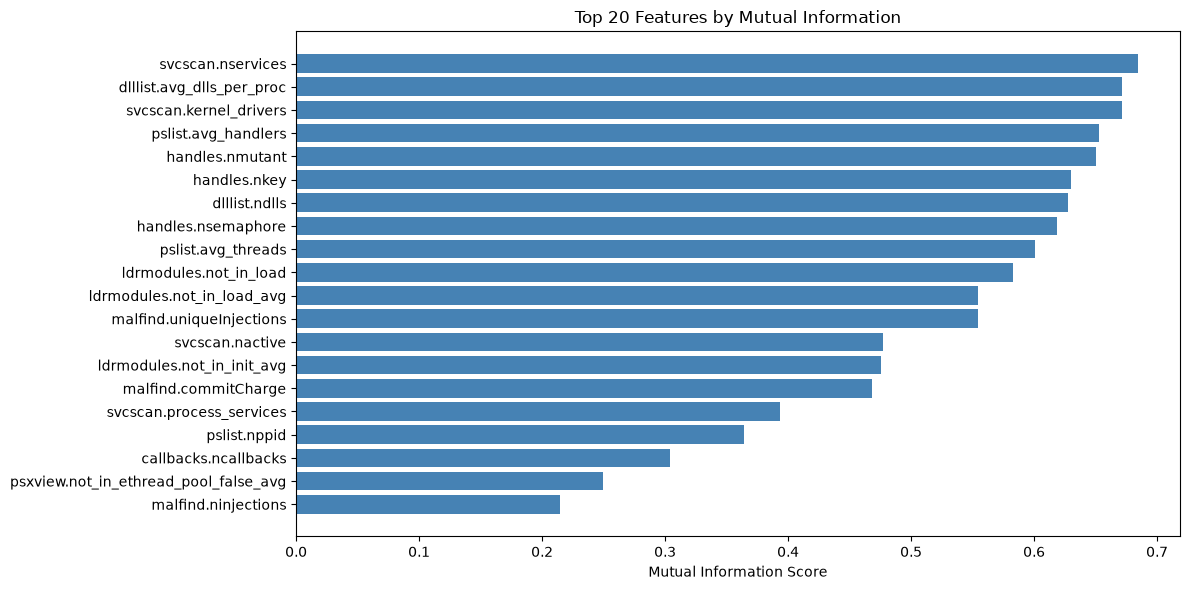

In [4]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train_filtered, y_train, random_state=42)
mi_df = pd.DataFrame({
    'feature': X_train_filtered.columns,
    'MI_score': mi_scores
}).sort_values('MI_score', ascending=False)

print("Top 20 features by Mutual Information:")
print(mi_df.head(20).to_string(index=False))

# Plot
plt.figure(figsize=(12, 6))
plt.barh(mi_df.head(20)['feature'][::-1], mi_df.head(20)['MI_score'][::-1], color='steelblue')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features by Mutual Information')
plt.tight_layout()
plt.savefig("results/figures/mutual_information_scores.png", dpi=300)
plt.show()

In [5]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

print("Running RFECV")
rf_rfe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfe = RFECV(rf_rfe, step=1, cv=5, scoring='f1', n_jobs=-1)
rfe.fit(X_train_filtered, y_train)

rfe_df = pd.DataFrame({
    'feature': X_train_filtered.columns,
    'RFE_rank': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('RFE_rank')

print(f"\nOptimal number of features: {rfe.n_features_}")
print(f"\nTop 20 features by RFE:")
print(rfe_df.head(20).to_string(index=False))

Running RFECV

Optimal number of features: 22

Top 20 features by RFE:
                              feature  RFE_rank  Selected
                         pslist.nproc         1      True
                 callbacks.ncallbacks         1      True
                      svcscan.nactive         1      True
             svcscan.process_services         1      True
               svcscan.kernel_drivers         1      True
                    svcscan.nservices         1      True
psxview.not_in_ethread_pool_false_avg         1      True
             malfind.uniqueInjections         1      True
                  malfind.ninjections         1      True
           ldrmodules.not_in_init_avg         1      True
           ldrmodules.not_in_load_avg         1      True
               ldrmodules.not_in_load         1      True
                 malfind.commitCharge         1      True
                   handles.nsemaphore         1      True
                         pslist.nppid         1      True
 

In [7]:
import shap

print("Computing SHAP importances")
rf_shap = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_shap.fit(X_train_filtered, y_train)

explainer = shap.TreeExplainer(rf_shap)
X_sample = X_train_filtered.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_imp = np.abs(shap_values[1]).mean(axis=0)
elif shap_values.ndim == 3:
    shap_imp = np.abs(shap_values[:, :, 1]).mean(axis=0)
else:
    shap_imp = np.abs(shap_values).mean(axis=0)

# Make sure it's 1D
shap_imp = np.array(shap_imp).flatten()

shap_df = pd.DataFrame({
    'feature': X_train_filtered.columns.tolist(),
    'SHAP_importance': shap_imp
}).sort_values('SHAP_importance', ascending=False)

print("\nTop 20 features by SHAP:")
print(shap_df.head(20).to_string(index=False))

Computing SHAP importances

Top 20 features by SHAP:
                   feature  SHAP_importance
         svcscan.nservices         0.104939
    svcscan.kernel_drivers         0.060045
 dlllist.avg_dlls_per_proc         0.054145
  svcscan.process_services         0.053713
       pslist.avg_handlers         0.045334
           handles.nmutant         0.040720
              handles.nkey         0.027661
        handles.nsemaphore         0.025443
             dlllist.ndlls         0.021210
      callbacks.ncallbacks         0.014854
        pslist.avg_threads         0.013988
           svcscan.nactive         0.011753
ldrmodules.not_in_load_avg         0.011281
    ldrmodules.not_in_load         0.008631
  malfind.uniqueInjections         0.008049
      malfind.commitCharge         0.006405
              pslist.nppid         0.004917
ldrmodules.not_in_init_avg         0.003066
       malfind.ninjections         0.002814
              pslist.nproc         0.002125


In [8]:
# Merge all rankings
consensus = mi_df.merge(rfe_df[['feature', 'RFE_rank']], on='feature')
consensus = consensus.merge(shap_df, on='feature')

# Normalise each score to 0-1
consensus['MI_norm'] = consensus['MI_score'] / consensus['MI_score'].max()
consensus['RFE_norm'] = 1 - (consensus['RFE_rank'] - 1) / (consensus['RFE_rank'].max() - 1)
consensus['SHAP_norm'] = consensus['SHAP_importance'] / consensus['SHAP_importance'].max()

# Consensus score: weighted average
consensus['consensus_score'] = (
    0.33 * consensus['MI_norm'] +
    0.33 * consensus['RFE_norm'] +
    0.34 * consensus['SHAP_norm']
)
consensus = consensus.sort_values('consensus_score', ascending=False)

print("CONSENSUS FEATURE RANKING (All features):")
print(consensus[['feature', 'MI_norm', 'RFE_norm', 'SHAP_norm', 'consensus_score']].to_string(index=False))

# Select top features (those with consensus > 0.3, or at minimum top 15-20)
selected_features = consensus.head(20)['feature'].tolist()
print(f"\n{'='*50}")
print(f"SELECTED {len(selected_features)} FEATURES:")
for i, f in enumerate(selected_features, 1):
    score = consensus[consensus['feature']==f]['consensus_score'].values[0]
    print(f"  {i:2d}. {f:40s} (score: {score:.4f})")

CONSENSUS FEATURE RANKING (All features):
                               feature  MI_norm  RFE_norm  SHAP_norm  consensus_score
                     svcscan.nservices 1.000000  1.000000   1.000000         1.000000
                svcscan.kernel_drivers 0.981099  1.000000   0.572190         0.848307
             dlllist.avg_dlls_per_proc 0.981176  1.000000   0.515964         0.829216
                   pslist.avg_handlers 0.953492  1.000000   0.432002         0.791533
                       handles.nmutant 0.950387  1.000000   0.388031         0.775558
                          handles.nkey 0.920049  1.000000   0.263589         0.723236
                    handles.nsemaphore 0.904376  1.000000   0.242452         0.710878
                         dlllist.ndlls 0.916513  1.000000   0.202121         0.701171
              svcscan.process_services 0.574975  1.000000   0.511849         0.693770
                    pslist.avg_threads 0.877579  1.000000   0.133296         0.664922
            

In [9]:
X_train_selected = X_train_filtered[selected_features]
X_test_selected = X_test_filtered[selected_features]

print(f"Final feature set: {X_train_selected.shape[1]} features")
print(f"Train: {X_train_selected.shape}")
print(f"Test:  {X_test_selected.shape}")

# Save for next notebook
X_train_selected.to_csv("data/X_train_selected.csv", index=True)
X_test_selected.to_csv("data/X_test_selected.csv", index=True)
y_train.to_csv("data/y_train.csv", index=True)
y_test.to_csv("data/y_test.csv", index=True)

# Also save unscaled versions for tree-based models
X_train_unscaled = X_train[selected_features]
X_test_unscaled = X_test[selected_features]
X_train_unscaled.to_csv("data/X_train_unscaled.csv", index=True)
X_test_unscaled.to_csv("data/X_test_unscaled.csv", index=True)

print("\nAll data saved to data/ folder")
print("FEATURE SELECTION COMPLETE. Ready for model training.")

Final feature set: 20 features
Train: (46876, 20)
Test:  (11720, 20)

All data saved to data/ folder
FEATURE SELECTION COMPLETE. Ready for model training.
